# Métricas e comparação dos modelos YOLOv11

Este notebook visualiza as **métricas de detecção** dos modelos treinados no dataset **Urban Disaster Monitor**. Os valores exibidos nos gráficos são obtidos nas **validações** de cada modelo (comando `yolo val` no conjunto de validação), e não no treinamento.

Serão mostrados:

- **mAP@0.5 global por variante** — desempenho geral de cada modelo (nano, small, medium, large)
- **mAP@0.5 por classe** — desempenho por classe (civilian, rescuer, dog, cat, horse, cow)

Os dados correspondem aos resultados de validação dos modelos YOLOv11n, YOLOv11s, YOLOv11m e YOLOv11l.

---
**Projeto:** [Urban Disaster Monitor](https://github.com/MariaCarolinass/urban-disaster-monitor) · **Autores:** Carolina Soares, João Galdino

## Gerar dados de validação

In [ ]:
!yolo val model=../models/yolov11n/best.pt data=../dataset/data.yaml imgsz=640

In [ ]:
!yolo val model=../models/yolov11s/best.pt data=../dataset/data.yaml imgsz=640

In [ ]:
!yolo val model=../models/yolov11m/best.pt data=../dataset/data.yaml imgsz=640

In [ ]:
!yolo val model=../models/yolov11l/best.pt data=../dataset/data.yaml imgsz=640

## 1. mAP@0.5 global por variante

O gráfico compara o **mAP@0.5** (mean Average Precision com IoU 0.5) entre as variantes YOLOv11 (nano, small, medium, large). A variante YOLOv11s obteve o melhor desempenho (0.8688).

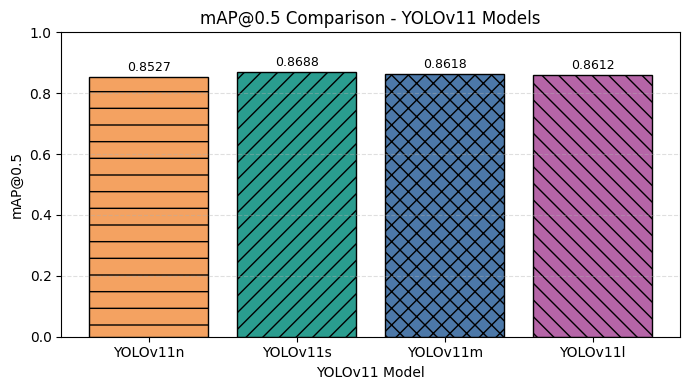

In [3]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ["YOLOv11n", "YOLOv11s", "YOLOv11m", "YOLOv11l"]
map50 = [0.8527, 0.8688, 0.8618, 0.8612]

cores = ["#F4A261", "#2A9D8F", "#4C78A8", "#B565A7"]
hachuras = ["-", "//", "xx", "\\\\"]

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(modelos, map50, color=cores, edgecolor="black")
for b, h in zip(barras, hachuras):
    b.set_hatch(h)
for b, v in zip(barras, map50):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_title("mAP@0.5 Comparison - YOLOv11 Models")
ax.set_ylabel("mAP@0.5")
ax.set_xlabel("YOLOv11 Model")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()

## 2. mAP@0.5 por classe

Este gráfico mostra o mAP@0.5 **por classe** (cat, civilian, cow, dog, horse, rescuer) para cada variante, permitindo ver em quais classes cada modelo se sai melhor ou pior e comparar o comportamento entre variantes.

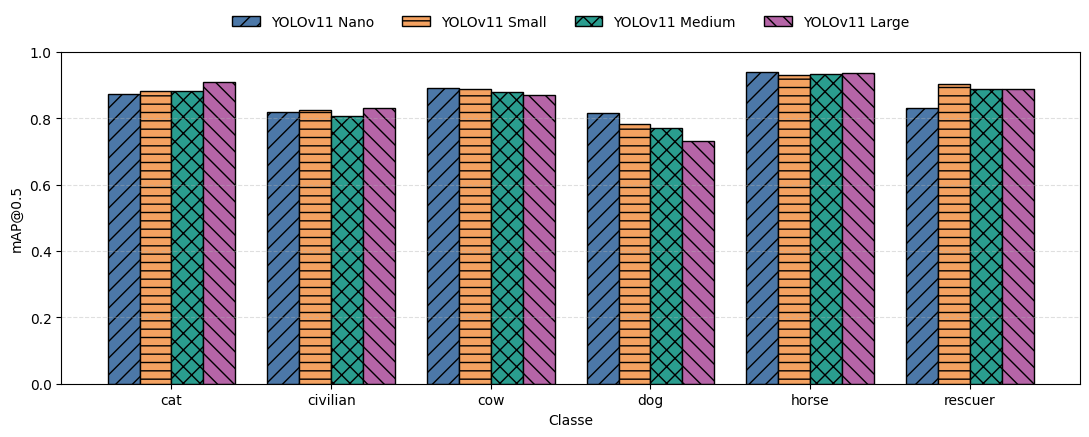

In [4]:
classes = ["cat", "civilian", "cow", "dog", "horse", "rescuer"]
# mAP@0.5 por classe (nano, small, medium, large)
yolo_n = [0.872, 0.819, 0.893, 0.816, 0.941, 0.830]
yolo_s = [0.884, 0.826, 0.888, 0.782, 0.932, 0.905]
yolo_m = [0.883, 0.807, 0.881, 0.772, 0.935, 0.889]
yolo_l = [0.910, 0.831, 0.870, 0.731, 0.936, 0.890]

x = np.arange(len(classes))
width = 0.2
colors = {"n": "#4C78A8", "s": "#F4A261", "m": "#2A9D8F", "l": "#B565A7"}

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - 1.5 * width, yolo_n, width, label="YOLOv11 Nano", color=colors["n"], edgecolor="black", hatch="//")
ax.bar(x - 0.5 * width, yolo_s, width, label="YOLOv11 Small", color=colors["s"], edgecolor="black", hatch="--")
ax.bar(x + 0.5 * width, yolo_m, width, label="YOLOv11 Medium", color=colors["m"], edgecolor="black", hatch="xx")
ax.bar(x + 1.5 * width, yolo_l, width, label="YOLOv11 Large", color=colors["l"], edgecolor="black", hatch="\\\\")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("mAP@0.5")
ax.set_xlabel("Classe")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=4, frameon=False)
fig.tight_layout()
plt.show()